# Fairness audit of 30-day readmission prediction (UCI Diabetes 130-US)

*Machine Learning and Data Mining, University of Bologna, A.Y. 2026/27 — Option 2, CRISP-DM.*

The binding method is the approved proposal, `docs/APPROVED_PROPOSAL.md`. The code is the
`readmission/` package; the full run is made by five scripts (§7). This notebook does two things:

* **Live part (§2–§4, §5.1):** it loads the data, builds the cohort and the patient-level splits,
  and fits **one** of the outer splits with the package's own code, so every step can be seen
  running.
* **Saved full results (§5.2–§5.6):** every table and figure of the paper comes from the five summary
  JSONs in `outputs/approved/`, written by the full run (all outer splits, patient bootstrap).
  The full run takes hours on Colab's CPUs, so it is not repeated here (§7 can do it).

No number in the text is typed by hand: each one is printed by the code cell above it or read
from the JSONs. Report sections are cited as, e.g., "approved_fairness.md §3.2"
(`outputs/reports/`).

**Colab:** *Runtime → Run all*. The setup cell looks for the repository in the working folder
(`/content` in Colab), in the folders above it and in the folders one level below it; if it is
not there, it unpacks a repository zip in the working folder, or clones the repository if it is
public. Alternatively, download it on GitHub (*Code → Download ZIP*) and either put
the zip into `/content` (Files pane) before *Run all*, or upload it when the setup cell asks.

## 0 Setup

`LIVE_SPLIT = True` fits one outer split live (its run time is printed in §4). `RUN_FULL` reruns
the whole protocol (§7) and stays `False`. Colab has 2 vCPUs, hence `N_THREADS = 2`.

The setup cell downloads the UCI data from `archive.ics.uci.edu` (SHA-256 checked by
`data/download.py`). If that site cannot be reached, the cell stops with an error: the script's
fallback (the `ucimlrepo` package) rebuilds a CSV whose bytes do not match the checked file, so it
is deliberately not relied on. Run the cell again later, or upload `data/raw/diabetic_data.csv`.

In [1]:
LIVE_SPLIT = True  # fit repeat 0, fold 0 live (§4)
RUN_FULL = False  # rerun the whole protocol with the five scripts (§7); takes hours
N_THREADS = 2  # CPU threads for fitting (readmission/runtime.py)
REPO_URL = "https://github.com/uygarcatal6/readmission-fairness-audit"

In [2]:
import os
import subprocess
import sys
import time
import warnings
import zipfile
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules


def find_repo(start: Path) -> Path | None:
    # the repository root is the folder that holds readmission/cohort.py: this folder, a folder
    # above it, or a folder one level below it (Colab runs in /content; an uploaded or cloned
    # repository sits in /content/<folder>)
    below = sorted(p for p in start.iterdir() if p.is_dir())
    for folder in [start, *start.parents, *below]:
        if (folder / "readmission" / "cohort.py").exists():
            return folder
    return None


def unpack_zip(folder: Path) -> None:
    # a repository zip in the working folder (GitHub: Code -> Download ZIP) is unpacked in place
    for archive in sorted(folder.glob("*.zip")):
        with zipfile.ZipFile(archive) as z:
            if any(name.endswith("readmission/cohort.py") for name in z.namelist()):
                z.extractall(folder)


ROOT = find_repo(Path.cwd())
if ROOT is None:  # opened on its own (e.g. in Colab): an uploaded zip, else a clone, else ask
    unpack_zip(Path.cwd())
    ROOT = find_repo(Path.cwd())
if ROOT is None:  # works when the repository is public (a private one needs the zip below)
    target = Path.cwd() / "readmission-fairness-audit"
    clone = subprocess.run(
        ["git", "clone", "--depth", "1", REPO_URL, str(target)],
        env={**os.environ, "GIT_TERMINAL_PROMPT": "0"},
    )
    ROOT = target if clone.returncode == 0 else None
if ROOT is None and IN_COLAB:  # no clone: upload the zip GitHub gives you
    from google.colab import files

    print("Upload the repository zip (on GitHub: Code -> Download ZIP).")
    files.upload()  # saved in the working folder
    unpack_zip(Path.cwd())
    ROOT = find_repo(Path.cwd())
if ROOT is None:
    raise RuntimeError(
        "repository not found: put the zip from GitHub (Code -> Download ZIP) or the unpacked "
        "folder into the working folder and run the cell again"
    )
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if IN_COLAB:  # Colab has most packages; this pins scikit-learn to the version of the project
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-colab.txt"], check=True
    )

RAW_CSV = ROOT / "data" / "raw" / "diabetic_data.csv"
if not RAW_CSV.exists():  # public UCI archive, SHA-256 verified by the script
    subprocess.run([sys.executable, "data/download.py"], check=True)
print("repository folder:", ROOT.name, "| in Colab:", IN_COLAB, "| data present:", RAW_CSV.exists())

# tqdm (imported by a dependency) warns about missing progress-bar widgets; not about results
warnings.filterwarnings("ignore", message="IProgress not found")

repository folder: readmission-fairness-audit | in Colab: False | data present: True


In [3]:
import matplotlib.pyplot as plt  # loads the inline backend, so figures display in the notebook
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.metrics import average_precision_score, roc_auc_score

from readmission import cohort, evaluate, fairness, figures, runtime, splits
from readmission.preprocess import make_preprocessor

print("CPU threads used:", runtime.cap_threads(N_THREADS))
print("scikit-learn", sklearn.__version__, "| pandas", pd.__version__, "| numpy", np.__version__)
assert sklearn.__version__.startswith("1.6"), (
    "the project pins scikit-learn 1.6 (requirements-colab.txt); in Colab restart the session "
    "(Runtime → Restart session) and run all cells again"
)

plt.rcParams["figure.dpi"] = 150  # sharper inline figures
pd.set_option("display.precision", 3)
pd.set_option("display.max_colwidth", 60)
results = figures.load_results(ROOT)  # the five summary JSONs of the full run (§5)


def ci(d: dict, digits: int = 3, key: str = "estimate") -> str:
    # "estimate [low, high]" from a JSON entry {estimate | difference, ci}
    lo, hi = d["ci"]
    return f"{d[key]:.{digits}f} [{lo:.{digits}f}, {hi:.{digits}f}]"

CPU threads used: 2
scikit-learn 1.6.1 | pandas 3.0.1 | numpy 2.4.3


## 1 Business understanding

A hospital can follow up only a fixed number of discharged diabetic patients to prevent a
readmission within 30 days. A model ranks the encounters by risk and the hospital follows up the
highest-risk **q %**, where q is the readmission rate of the training data (a fixed capacity that
reads no test labels; `readmission/decision.py`).

Two questions, both fixed in the approved proposal before the results:

1. **Is the model usable?** Only if the lower 95 % confidence bound of (accuracy − no-information
   rate) is above zero. ROC-AUC, PR-AUC against the prevalence and the Brier skill score are
   reported next to it.
2. **Are the errors equal across sex, age band and race?** Equalized odds: the same TPR (share of
   readmitted patients who are flagged) and FPR (share of the others who are flagged) in every
   group. If not, where does the gap come from (inputs, ranking, measurement) and what does a
   mitigation cost?

The protocol constants below are read from the package and from the saved run.

In [4]:
cfg = evaluate.Config()
protocol = {
    "outer folds x repeats": f"{cfg.n_splits} x {cfg.n_repeats}",
    "inner folds (tuning, Youden threshold)": cfg.n_inner,
    "approved models": ", ".join(cfg.models),
    "course-topic extensions": ", ".join(cfg.extensions),
    "patient-bootstrap draws (saved run)": results["summary"]["n_boot"],
    "min positives / negatives per group": f"{fairness.MIN_POSITIVES} / {fairness.MIN_NEGATIVES}",
    "permutations for the no-disparity null": results["fairness"]["n_permutations"],
    "seed": cfg.seed,
}
pd.Series(protocol, name="value").to_frame()

,value
outer folds x repeats,5 x 5
"inner folds (tuning, Youden threshold)",5
approved models,"logreg, tree, knn, rf, hgb"
course-topic extensions,"mlp, bagging"
patient-bootstrap draws (saved run),1000
min positives / negatives per group,50 / 50
permutations for the no-disparity null,200
seed,0


## 2 Data understanding

The raw UCI file: one row per inpatient encounter; `patient_nbr` identifies the patient; `?` is the
missing-value code; `readmitted` is `<30`, `>30` or `NO`.

In [5]:
raw = pd.read_csv(RAW_CSV, dtype=str, keep_default_na=False)  # keep "None" and "?" as text
print(
    f"encounters {len(raw):,} | patients {raw['patient_nbr'].nunique():,} | columns {raw.shape[1]}"
)
raw["readmitted"].value_counts(normalize=True).rename("share").to_frame()

encounters 101,766 | patients 71,518 | columns 50


,share
readmitted,
NO,0.539
>30,0.349
<30,0.112


In [6]:
missing = {
    col: (raw[col] == "?").mean() for col in ("weight", "payer_code", "medical_specialty", "race")
}
pd.Series(missing, name="share missing ('?')").to_frame()

,share missing ('?')
weight,0.969
payer_code,0.396
medical_specialty,0.491
race,0.022


**`weight` is dropped:** the share printed above is missing, so it cannot be learned from and
imputing it would invent almost the whole column. `payer_code` and `medical_specialty` are also
often missing but are kept: their `?` becomes its own level ("unknown"), because *whether* a payer
or specialty was recorded can itself carry information. Race `?` becomes "Unknown", which is a
missing-value code, not a racial group: it stays in the tables but not in the race gaps
(`readmission/fairness.py`, `NOT_A_GROUP`).

In [7]:
df, funnel = cohort.load_cohort(RAW_CSV, return_report=True)
pd.Series(
    {k: f"{v:,}" if isinstance(v, int) else f"{v:.4f}" for k, v in funnel.items()}, name="value"
).to_frame()

,value
n_raw,"101,766"
excluded_unknown_sex,3
excluded_death_hospice,"2,423"
excluded_missing_primary_diagnosis,20
excluded_paediatric,850
excluded_repeat_encounters,0
n_encounters,"98,470"
n_patients,"69,303"
n_positive,"11,266"
prevalence,0.1144


The exclusion funnel of `readmission/cohort.py`: unknown sex, discharges to death or hospice
(cannot be readmitted), missing primary diagnosis, and the two paediatric age bands. The target is
`y = 1` if readmitted within 30 days, else 0. Base rates by group (the readmission rate itself,
before any model):

In [8]:
base = (
    df.melt(
        id_vars=[cohort.TARGET],
        value_vars=list(cohort.SENSITIVE),
        var_name="attribute",
        value_name="group",
    )
    .groupby(["attribute", "group"])[cohort.TARGET]
    .agg(encounters="size", readmitted="sum", base_rate="mean")
)
base

encounters  readmitted  base_rate
attribute group                                             
age_band  20-39                  5412         660      0.122
          40-59                 26663        2690      0.101
          60-79                 47377        5545      0.117
          80+                   19018        2371      0.125
race      AfricanAmerican       18538        2135      0.115
          Asian                   624          65      0.104
          Caucasian             73640        8525      0.116
          Hispanic               1990         210      0.106
          Other                  1457         143      0.098
          Unknown                2221         188      0.085
sex       Female                52965        6102      0.115
          Male                  45505        5164      0.113

## 3 Data preparation

The model inputs are raw attributes grouped in blocks (counts printed below; the blocks are used
again in the source analysis, approved_sources.md §1). The sensitive attributes are inputs too (age as the band midpoint, sex,
race); `age_band` is only used to group the results.

In [9]:
blocks = results["sources"]["blocks"]
print("inputs:", len(cohort.FEATURES), "| in the blocks:", sum(len(v) for v in blocks.values()))
pd.Series({b: ", ".join(cols) for b, cols in blocks.items()}, name="inputs").to_frame()

inputs: 23 | in the blocks: 23


,inputs
demographics,"age, sex, race"
prior_use,"number_outpatient, number_emergency, number_inpatient"
current_stay,"time_in_hospital, num_lab_procedures, num_procedures, nu..."
admission,"admission_type, admission_source, discharge_group, medic..."
diagnosis,diag_1_group
diabetes_care,"a1c_result, max_glu_serum, insulin, metformin, med_chang..."


**Patient-level splits** (`readmission/splits.py`): a patient has several encounters, so all of a
patient's encounters go to the same fold; otherwise the model would be tested on patients it has
seen. `StratifiedGroupKFold` also keeps the readmission rate of every fold close to the cohort's.
Repeat 0 of the outer splits:

In [10]:
y = df[cohort.TARGET].to_numpy()
g = df[cohort.GROUP].to_numpy()
rows = []
for s in splits.outer_splits(y, g, n_splits=cfg.n_splits, n_repeats=1, seed=cfg.seed):
    shared = set(g[s.train]) & set(g[s.test])  # patients in both parts: must be none
    rows.append(
        {
            "fold": s.fold,
            "train encounters": len(s.train),
            "test encounters": len(s.test),
            "test patients": len(set(g[s.test])),
            "train rate (= q)": y[s.train].mean(),
            "test rate": y[s.test].mean(),
            "patients in both": len(shared),
        }
    )
fold_table = pd.DataFrame(rows).set_index("fold")
with pd.option_context("display.precision", 4):  # four digits for the two rates
    display(fold_table)

,train encounters,test encounters,test patients,train rate (= q),test rate,patients in both
fold,,,,,,
0,78775,19695,13908,0.1144,0.1144,0
1,78777,19693,13846,0.1144,0.1144,0
2,78776,19694,13819,0.1144,0.1144,0
3,78776,19694,13893,0.1144,0.1145,0
4,78776,19694,13837,0.1144,0.1144,0


In [11]:
split0 = next(splits.outer_splits(y, g, n_splits=cfg.n_splits, n_repeats=1, seed=cfg.seed))
pre = make_preprocessor(cfg.features).fit(df.iloc[split0.train][list(cfg.features)])
X_example = pre.transform(df.iloc[split0.test][list(cfg.features)])
print(
    f"one-hot + scaling, fitted on the training fold only: {len(cfg.features)} inputs -> "
    f"{X_example.shape[1]} model columns"
)

one-hot + scaling, fitted on the training fold only: 23 inputs -> 88 model columns


The preprocessor (`readmission/preprocess.py`) scales the numeric inputs and one-hot encodes the
categorical ones, pooling rare levels; it is fitted on the training rows of each fold only, so the
test fold never shapes the encoding.

## 4 Modelling — one outer split, live

`evaluate.run_split` is the same function the full run calls for each of its outer splits. On the
training fold it runs the inner patient-level folds: the decision-tree depth and the k of k-NN are
chosen by the **one-SE rule** (the simplest value within one standard error of the best inner
ROC-AUC, `readmission/tuning.py`), and each model gets a Youden threshold from its inner
out-of-fold scores. It then refits every model on the whole training fold, scores the test fold
and applies the decision rules. To save time the two course-topic extensions (MLP and bagging)
are skipped here; the approved models and their class-weighted variants are all fitted.

In [12]:
live = None
if LIVE_SPLIT:
    live_cfg = evaluate.Config(extensions=())  # approved models only
    t0 = time.time()
    live = evaluate.run_split(df, split0, live_cfg)
    live_minutes = (time.time() - t0) / 60
    print(
        f"repeat {split0.repeat}, fold {split0.fold}: {live_minutes:.1f} min "
        f"with {runtime.resolve_n_jobs(N_THREADS)} CPU threads"
    )
else:
    print("LIVE_SPLIT is False: §4 and §5.1 are skipped")

repeat 0, fold 0: 3.5 min with 2 CPU threads


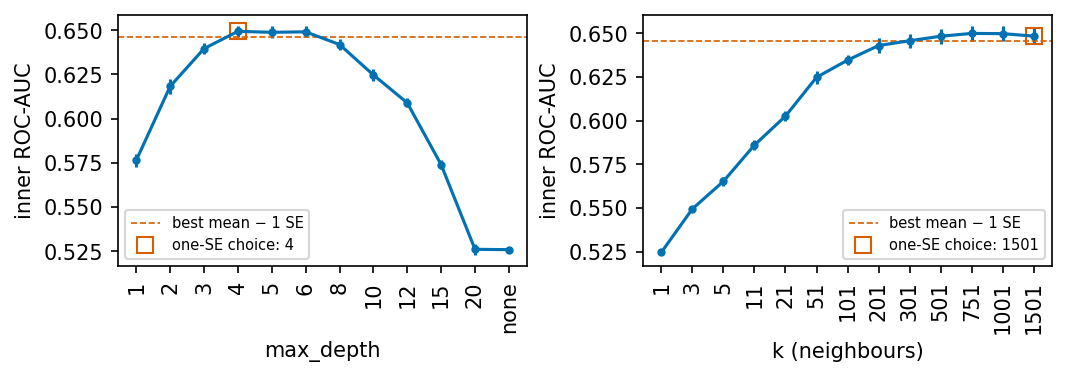

tree: one-SE choice 4, best mean at 4
knn: one-SE choice 1501, best mean at 751


In [13]:
if live is not None:
    fig, axes = plt.subplots(1, 2, figsize=(7, 2.4), layout="constrained")
    panels = (("tree", "max_depth"), ("knn", "k (neighbours)"))
    for ax, (m, label) in zip(axes, panels, strict=True):
        t = live["tuning"][m]
        grid = live_cfg.tree_depths if m == "tree" else live_cfg.knn_ks
        x = np.arange(len(grid))
        ax.errorbar(x, t["mean"], yerr=t["se"], fmt="o-", ms=3, color="#0072B2")
        ax.axhline(t["threshold"], color="#D55E00", ls="--", lw=0.8, label="best mean − 1 SE")
        ax.plot(
            t["index"],
            t["mean"][t["index"]],
            "s",
            ms=8,
            mfc="none",
            color="#D55E00",
            label=f"one-SE choice: {t['value']}",
        )
        ax.set_xticks(x, ["none" if v is None else str(v) for v in grid], rotation=90)
        ax.set_xlabel(label)
        ax.set_ylabel("inner ROC-AUC")
        ax.legend(fontsize=7)
    plt.show()
    for m, t in live["tuning"].items():
        print(f"{m}: one-SE choice {t['value']}, best mean at {t['best_value']}")

In [14]:
if live is not None:
    te = live["test"]
    y_te = y[te]
    k = round(live["q"] * len(te))  # capacity of this test fold
    rows = []
    for m, s in live["scores"].items():
        f = live["flags"][f"{m}__topq"]
        tp = int((f & (y_te == 1)).sum())
        rows.append(
            {
                "model": m,
                "ROC-AUC": roc_auc_score(y_te, s),
                "PR-AUC": average_precision_score(y_te, s),
                "flagged": int(f.sum()),
                "TPR": tp / (y_te == 1).sum(),
                "PPV": tp / f.sum(),
                "accuracy": ((f == 1) == (y_te == 1)).mean(),
            }
        )
    live_table = pd.DataFrame(rows).set_index("model")
    print(
        f"q = training-fold rate {live['q']:.4f} -> k = round(q * n) = {k} of {len(te):,} test "
        f"encounters flagged; readmitted in this test fold: {int(y_te.sum())}"
    )
    print(f"test prevalence {y_te.mean():.4f}, no-information rate {1 - y_te.mean():.4f}")
    display(live_table)

q = training-fold rate 0.1144 -> k = round(q * n) = 2253 of 19,695 test encounters flagged; readmitted in this test fold: 2253
test prevalence 0.1144, no-information rate 0.8856


,ROC-AUC,PR-AUC,flagged,TPR,PPV,accuracy
model,,,,,,
logreg,0.651,0.201,2253,0.224,0.224,0.822
tree,0.644,0.192,2253,0.230,0.230,0.824
knn,0.645,0.203,2253,0.227,0.227,0.823
rf,0.662,0.216,2253,0.248,0.248,0.828
hgb,0.661,0.211,2253,0.247,0.247,0.828


Every model flags exactly k encounters (`decision.flag_top_q`). TPR = TP / readmitted and
PPV = TP / flagged, so the two are equal when the number flagged equals the number readmitted in
the fold (both printed above): q is the training-fold rate, and the stratified patient-level folds
keep the test-fold rate at about q. Over the full run the two therefore stay almost equal (§5.2).
At this prevalence accuracy can only beat the no-information rate if more than half of the flagged
encounters are readmitted (PPV > 0.5), which the PPV column shows is far from the case.

If the git-ignored checkpoints of the full run are present (only on the author's machine), the
cell below checks that this live split reproduces the saved one; in a fresh clone it says so and
moves on.

In [15]:
saved = ROOT / "outputs" / "approved" / "checkpoints" / "r0_f0.npz"
if live is not None and saved.exists():
    z = np.load(saved)
    same = {
        m: bool(
            np.array_equal(z[f"flag__{m}__topq"], live["flags"][f"{m}__topq"])
            and np.allclose(z[f"score__{m}"], live["scores"][m], atol=1e-6)
        )
        for m in live["scores"]
    }
    print("same test rows:", bool(np.array_equal(z["test"], live["test"])))
    print("same scores and flags:", same)
else:
    print("saved checkpoint r0_f0 not in this copy (outputs/approved/checkpoints is git-ignored)")

same test rows: True
same scores and flags: {'logreg': True, 'tree': True, 'knn': True, 'rf': True, 'hgb': True}


## 5 Evaluation

### 5.1 Fairness on the live fold (random forest, top q %)

TPR and FPR by group on this one test fold. A single fold holds only part of each group's
readmissions, so small groups fall below the minimum number of positives ("enough positives");
that is why the audit pools the out-of-fold flags of all folds of a repeat (approved proposal §3;
§5.3 below). Race "Unknown" is a missing-value code: it is shown but not used in the gaps
("in the gaps").

In [16]:
if live is not None:
    fold = df.iloc[te][["age_band", "sex", "race"]]
    fold = fold.assign(y=y_te, flag=live["flags"]["rf__topq"])
    rows = []
    for attr in ("age_band", "sex", "race"):
        for grp, part in fold.groupby(attr):  # groups in sorted order
            pos, neg = part[part.y == 1], part[part.y == 0]
            rows.append(
                {
                    "attribute": attr,
                    "group": grp,
                    "readmitted": len(pos),
                    "TPR": pos.flag.mean(),
                    "FPR": neg.flag.mean(),
                    "enough positives": len(pos) >= fairness.MIN_POSITIVES,
                    "in the gaps": grp not in fairness.NOT_A_GROUP.get(attr, ()),
                }
            )
    display(pd.DataFrame(rows).set_index(["attribute", "group"]))

readmitted    TPR    FPR  enough positives  \
attribute group                                                         
age_band  20-39                   129  0.457  0.131              True   
          40-59                   524  0.269  0.084              True   
          60-79                  1088  0.235  0.094              True   
          80+                     512  0.199  0.114              True   
sex       Female                 1237  0.265  0.104              True   
          Male                   1016  0.226  0.089              True   
race      AfricanAmerican         423  0.258  0.106              True   
          Asian                     7  0.286  0.057             False   
          Caucasian              1732  0.245  0.096              True   
          Hispanic                 34  0.441  0.101             False   
          Other                    27  0.111  0.076             False   
          Unknown                  30  0.167  0.070             False   

                           in the gaps  
attribute group                         
age_band  20-39                   True  
          40-59                   True  
          60-79                   True  
          80+                     True  
sex       Female                  True  
          Male                    True  
race      AfricanAmerican         True  
          Asian                   True  
          Caucasian               True  
          Hispanic                True  
          Other                   True  
          Unknown                False

### 5.2 Saved full results: models and usability gate

From here on everything is read from the JSONs of the full run: all outer splits (the live split
above is repeat 0, fold 0 of them), point estimates averaged over the repeats, 95 % CIs from the
patient bootstrap (`readmission/metrics.py`).

outer splits 25 | repeats 5 | bootstrap draws 1000 | encounters 98,470 | prevalence 0.1144 | NIR 0.8856


,ROC-AUC,PR-AUC,Brier skill,accuracy − NIR (top q %),TPR,PPV,usable
model,,,,,,,
logreg,"0.653 [0.648, 0.659]","0.205 [0.196, 0.214]","0.034 [0.030, 0.038]","-0.0607 [-0.0635, -0.0578]","0.234 [0.224, 0.245]","0.235 [0.225, 0.244]",False
tree,"0.648 [0.642, 0.654]","0.202 [0.194, 0.211]","0.035 [0.032, 0.040]","-0.0600 [-0.0629, -0.0572]","0.238 [0.228, 0.249]","0.238 [0.229, 0.247]",False
knn,"0.650 [0.644, 0.656]","0.205 [0.196, 0.214]","0.030 [0.027, 0.033]","-0.0611 [-0.0640, -0.0582]","0.233 [0.222, 0.244]","0.233 [0.224, 0.242]",False
rf,"0.665 [0.659, 0.671]","0.216 [0.207, 0.225]","0.041 [0.038, 0.045]","-0.0566 [-0.0594, -0.0539]","0.252 [0.243, 0.264]","0.252 [0.244, 0.261]",False
hgb,"0.664 [0.659, 0.670]","0.214 [0.206, 0.223]","0.041 [0.037, 0.045]","-0.0571 [-0.0599, -0.0544]","0.250 [0.240, 0.261]","0.250 [0.242, 0.259]",False
mlp (extension),"0.644 [0.638, 0.649]","0.195 [0.188, 0.204]","0.016 [0.012, 0.022]","-0.0615 [-0.0639, -0.0589]","0.231 [0.222, 0.241]","0.231 [0.223, 0.240]",False
bagging (extension),"0.644 [0.639, 0.650]","0.201 [0.194, 0.210]","0.026 [0.022, 0.031]","-0.0608 [-0.0636, -0.0581]","0.234 [0.225, 0.244]","0.234 [0.226, 0.243]",False


any model and decision rule usable: False


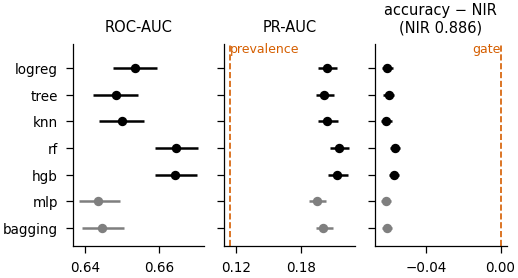

In [17]:
summary = results["summary"]
print(
    f"outer splits {len(summary['split_seconds'])} | repeats {summary['n_repeats']} | "
    f"bootstrap draws {summary['n_boot']} | encounters {summary['n_encounters']:,} | "
    f"prevalence {summary['prevalence']:.4f} | NIR {summary['nir']:.4f}"
)
rows = []
for m in cfg.models + cfg.extensions:
    r = summary["ranking"][f"model:{m}"]
    d = summary["decision"][f"{m}__topq"]
    rows.append(
        {
            "model": m + ("" if m in cfg.models else " (extension)"),
            "ROC-AUC": ci(r["roc_auc"]),
            "PR-AUC": ci(r["pr_auc"]),
            "Brier skill": ci(r["brier_skill"]),
            "accuracy − NIR (top q %)": ci(d["acc_minus_nir"], 4),
            "TPR": ci(d["tpr"]),
            "PPV": ci(d["ppv"]),
            "usable": d["usable"],
        }
    )
display(pd.DataFrame(rows).set_index("model"))
print("any model and decision rule usable:", any(d["usable"] for d in summary["decision"].values()))
figures.fig_models(summary)

Figure and table mirror approved_main.md §1–§2 (sensitivity rules: §3). Dots are point
estimates, bars 95 % CIs; the dashed line in the middle panel is the prevalence (what random
scores give as PR-AUC), the one on the right the usability gate.

,one-SE choice (value: splits),best mean (value: splits),choice at grid edge
tree,"{'4': 20, '5': 5}","{'4': 8, '5': 16, '6': 1}",0 of 25
knn,{'1501': 25},"{'751': 6, '1001': 18, '501': 1}",25 of 25


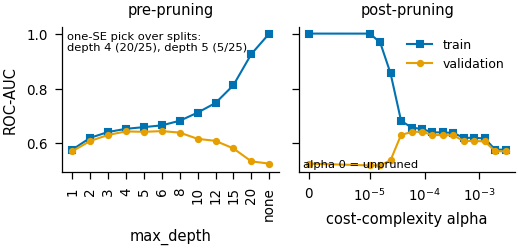

In [18]:
tuning = pd.DataFrame(
    {
        m: {
            "one-SE choice (value: splits)": t["chosen"],
            "best mean (value: splits)": t["best"],
            "choice at grid edge": f"{t['chosen_at_grid_edge']} of {t['n']}",
        }
        for m, t in summary["tuning"].items()
    }
).T
display(tuning)
figures.fig_complexity(summary)

Decision-tree complexity on the first outer split's first inner fold (approved_main.md §4): the
training ROC-AUC keeps rising with depth while the validation ROC-AUC peaks early and falls
(overfitting); cost-complexity pruning shows the same trade-off from the other side. The table
gives the one-SE picks over all outer splits (approved_main.md §5); k-NN chose the largest k of
the grid, so a wider grid could only pick an even simpler model.

### 5.3 Fairness audit (primary model, top q %)

The primary model is the approved model with the highest ROC-AUC; the leading attribute is the one
whose equalized-odds (EO) difference — the larger of the TPR gap and the FPR gap — lies furthest
above its **permutation null** (the gap expected with no disparity at all, from patient-level
shuffles of the attribute; `readmission/fairness.py`).

primary model: rf | leading attribute: age_band | by the raw range (first rule): age_band


,EO difference,TPR gap,FPR gap,null mean,permutation p
attribute,,,,,
sex,"0.016 [0.004, 0.038]","0.016 [0.001, 0.038]","0.008 [0.003, 0.012]",0.009,0.189
age_band,"0.257 [0.192, 0.320]","0.257 [0.192, 0.320]","0.045 [0.028, 0.062]",0.030,0.005
race,"0.081 [0.045, 0.223]","0.081 [0.042, 0.223]","0.031 [0.017, 0.057]",0.094,0.552
sex_x_age,"0.314 [0.228, 0.398]","0.314 [0.228, 0.398]","0.052 [0.038, 0.075]",0.064,0.005


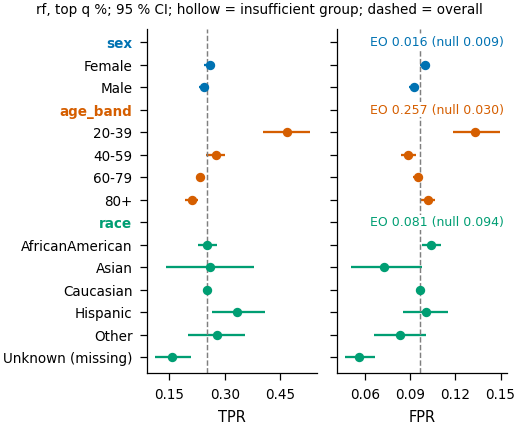

In [19]:
fair = results["fairness"]
key = f"{fair['primary_model']}__topq"
print(
    "primary model:",
    fair["primary_model"],
    "| leading attribute:",
    fair["leading_attribute"],
    "| by the raw range (first rule):",
    fair["leading_attribute_raw"],
)
rows = []
for a in fairness.MAIN_ATTRIBUTES + ("sex_x_age",):
    gp = fair["gaps"][key][a]
    rows.append(
        {
            "attribute": a,
            "EO difference": ci(gp["eo_diff"]),
            "TPR gap": ci(gp["tpr_gap"]),
            "FPR gap": ci(gp["fpr_gap"]),
            "null mean": gp["null"]["mean"],
            "permutation p": gp["null"]["p_value"],
        }
    )
display(pd.DataFrame(rows).set_index("attribute"))
figures.fig_fairness(fair, overall=summary["decision"][key])

Table: approved_fairness.md §2; figure: §3.1–§3.3. The age-band gap is far above its null; the
sex gap is small and within its null; the race range is below its null mean (many small groups
make a large range likely by chance). Calibration by age band (approved_fairness.md §4):
observed − predicted risk per group, and the expected calibration error next to the value a
perfectly calibrated model would show in a group of that size.

In [20]:
cal = fair["calibration"][fair["primary_model"]]["age_band"]
pd.DataFrame(
    {
        grp: {
            "observed − predicted": ci(c["citl"]),
            "ECE": c["ece"],
            "ECE if perfectly calibrated": c["ece_if_perfectly_calibrated"],
        }
        for grp, c in cal.items()
    }
).T

,observed − predicted,ECE,ECE if perfectly calibrated
20-39,"0.003 [-0.008, 0.014]",0.022,0.01
40-59,"-0.004 [-0.008, -0.000]",0.009,0.005
60-79,"0.002 [-0.001, 0.005]",0.005,0.003
80+,"-0.002 [-0.007, 0.003]",0.008,0.006


### 5.4 Mitigation (leading attribute)

Each mitigated arm is compared with its unconstrained twin under the same rule, on the same
bootstrap draw (approved_mitigation.md §1–§3). Reweighing refits with Kamiran–Calders weights or
cell balancing; *EO at capacity* post-processes the scores so every group gets the same TPR and FPR
while q % are flagged; fairlearn's ThresholdOptimizer does the same at its own (much larger)
share, so it is compared with the same model flagging exactly as many.

,EO age_band (twin → arm),Δ EO,Δ accuracy,share flagged,usable
arm,,,,,
K&C reweighing,0.257 → 0.293,"0.036 [0.026, 0.045]","-0.0002 [-0.0007, 0.0004]",0.114,False
cell balancing,0.257 → 0.146,"-0.111 [-0.137, -0.087]","-0.0010 [-0.0019, -0.0000]",0.114,False
EO at capacity,0.250 → 0.018,"-0.232 [-0.269, -0.146]","-0.0090 [-0.0100, -0.0081]",0.115,False
ThresholdOptimizer (vs same-number twin),0.187 → 0.018,"-0.169 [-0.179, -0.134]","-0.0123 [-0.0136, -0.0109]",0.365,False


,baseline,top q % (80 % model),EO at capacity,single threshold,ThresholdOptimizer
TPR by age_band,,,,,
20-39,0.468,0.457,0.222,0.668,0.510
40-59,0.276,0.274,0.213,0.540,0.522
60-79,0.233,0.234,0.215,0.559,0.521
80+,0.211,0.207,0.204,0.606,0.504


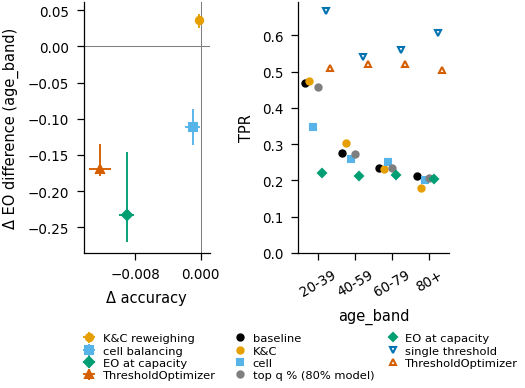

In [21]:
mitig = results["mitigation"]
a = mitig["leading_attribute"]
arms = [
    ("K&C reweighing", f"rw_kc_{a}@topq", f"rw_kc_{a}__topq"),
    ("cell balancing", f"rw_cell_{a}@topq", f"rw_cell_{a}__topq"),
    ("EO at capacity", f"eocap_{a}", f"eocap_{a}__eo"),
    ("ThresholdOptimizer (vs same-number twin)", f"to_samek_{a}", f"to_{a}__eo"),
]
rows = []
for label, eff_key, audit_key in arms:
    e = mitig["effects"][eff_key]
    eo = e[f"eo_{a}"]
    rows.append(
        {
            "arm": label,
            f"EO {a} (twin → arm)": f"{eo['counterpart']:.3f} → {eo['mitigated']:.3f}",
            "Δ EO": ci(eo, key="difference"),
            "Δ accuracy": ci(e["accuracy"], 4, "difference"),
            "share flagged": mitig["audit"]["overall_selection"][audit_key],
            "usable": mitig["summary"]["decision"][audit_key]["usable"],
        }
    )
display(pd.DataFrame(rows).set_index("arm"))

groups = mitig["audit"]["groups"][a]
columns = (
    ("baseline", "base__topq"),
    ("top q % (80 % model)", "val__topq"),
    ("EO at capacity", f"eocap_{a}__eo"),
    ("single threshold", "val__youden"),
    ("ThresholdOptimizer", f"to_{a}__eo"),
)
tpr_table = pd.DataFrame(
    {
        label: {grp: groups[grp]["metrics"][k]["tpr"]["estimate"] for grp in groups}
        for label, k in columns
    }
)
display(tpr_table.rename_axis(f"TPR by {a}"))
figures.fig_mitigation(mitig)

Left panel: Δ EO against Δ accuracy (approved_mitigation.md §1–§3). Right panel and the TPR
table: TPR by group per arm (approved_mitigation.md §5.1). The post-processors are fitted on a
hold-out part of each training fold, so they start from a model fitted on the other 80 %: the
"top q % (80 % model)" column is that model under the capacity rule, the start of EO at capacity.
Filled markers flag about q %, hollow markers (single threshold, ThresholdOptimizer) flag far more,
so compare within each set. Read the TPR table column by column: the post-processors close the gap
by moving the high group down to the others, not the low groups up (**levelling down**).

### 5.5 Where the gap comes from (sources)

The primary model is refitted on the same splits without one block of inputs (ablation) or
without a sensitive attribute (unawareness). A weaker ranking alone can shrink a gap, so each arm
has a reference: the gap of the full model after losing the same ROC-AUC to random noise
(approved_sources.md §1–§2).

,Δ ROC-AUC,EO age_band (full → refit),Δ EO,"EO at same ROC-AUC loss, random (min–max)"
refit,,,,
− demographics,"-0.0032 [-0.0045, -0.0020]",0.257 → 0.188,"-0.069 [-0.086, -0.051]",0.252 (0.245–0.255)
− prior use,"-0.0450 [-0.0495, -0.0402]",0.257 → 0.080,"-0.177 [-0.236, -0.107]",0.164 (0.158–0.168)
− current stay,"-0.0080 [-0.0103, -0.0059]",0.257 → 0.257,"0.000 [-0.018, 0.018]",0.236 (0.231–0.241)
− admission block,"-0.0302 [-0.0339, -0.0266]",0.257 → 0.303,"0.046 [0.025, 0.072]",0.196 (0.184–0.204)
− diagnosis,"-0.0033 [-0.0045, -0.0021]",0.257 → 0.248,"-0.009 [-0.021, 0.004]",0.246 (0.236–0.252)
− diabetes care,"-0.0023 [-0.0040, -0.0006]",0.257 → 0.264,"0.007 [-0.011, 0.024]",0.251 (0.249–0.255)
− sex,"-0.0005 [-0.0013, 0.0002]",0.257 → 0.258,"0.001 [-0.010, 0.011]",0.255 (0.251–0.259)
− race,"-0.0009 [-0.0016, -0.0002]",0.257 → 0.260,"0.003 [-0.005, 0.013]",0.255 (0.253–0.256)
− age,"-0.0027 [-0.0037, -0.0017]",0.257 → 0.187,"-0.070 [-0.086, -0.052]",0.254 (0.249–0.257)


,proxy ROC-AUC (other inputs → attribute)
sex,"0.626 [0.622, 0.630]"
age_band,"0.773 [0.770, 0.775]"
race,"0.716 [0.709, 0.723]"


,readmitted,within-group ROC-AUC,TPR,TPR at the overall FPR,shared cut-off effect
20-39,660,"0.755 [0.729, 0.783]",0.468,0.383,0.085
40-59,2690,"0.692 [0.681, 0.703]",0.276,0.294,-0.018
60-79,5545,"0.651 [0.643, 0.659]",0.233,0.236,-0.003
80+,2371,"0.616 [0.603, 0.628]",0.211,0.201,0.01


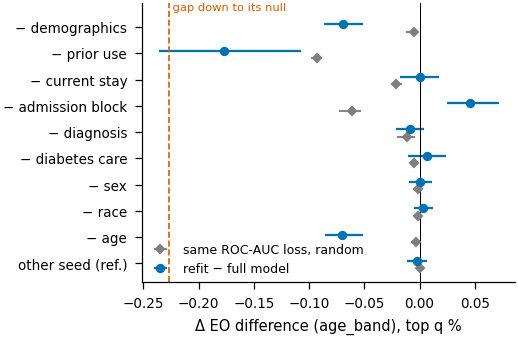

In [22]:
src = results["sources"]
a = src["leading_attribute"]
rows = []
for arm, label in figures.SOURCE_ARMS:
    e = src["effects"][f"{arm}@topq"]
    eo = e[f"eo_{a}"]
    d = src["degradation"][arm]
    random_eo = f"{d[f'eo_{a}']:.3f} ({d[f'eo_{a}_min']:.3f}–{d[f'eo_{a}_max']:.3f})"
    rows.append(
        {
            "refit": label,
            "Δ ROC-AUC": ci(e["roc_auc"], 4, "difference"),
            f"EO {a} (full → refit)": f"{eo['counterpart']:.3f} → {eo['mitigated']:.3f}",
            "Δ EO": ci(eo, key="difference"),
            "EO at same ROC-AUC loss, random (min–max)": random_eo,
        }
    )
display(pd.DataFrame(rows).set_index("refit"))
display(
    pd.DataFrame(
        {
            att: {"proxy ROC-AUC (other inputs → attribute)": ci(src["proxy"][att]["macro"])}
            for att in fairness.MAIN_ATTRIBUTES
        }
    ).T
)
display(
    pd.DataFrame(
        {
            grp: {
                "readmitted": r["n_pos"],
                "within-group ROC-AUC": ci(r["roc_auc"]),
                "TPR": r["tpr"],
                "TPR at the overall FPR": r["tpr_at_overall_fpr"],
                "shared cut-off effect": r["tpr"] - r["tpr_at_overall_fpr"],
            }
            for grp, r in src["ranking"][a].items()
        }
    ).T
)
figures.fig_sources(src)

Tables: approved_sources.md §1–§2 (refits), §4 (proxy check: how well the other inputs predict
each attribute) and §5 (ranking within groups). Figure: an arm far to the left of its grey
diamond removed inputs that carry the gap, not just predictive signal. Removing age narrows the
gap only partly because the other inputs still predict the age band (proxy table). The
within-group table separates two effects: the young band's TPR stays higher even when every band
is flagged at the overall FPR ("TPR at the overall FPR": the model ranks it better), and the
shared cut-off adds the rest (last column: TPR minus TPR at the overall FPR).

### 5.6 Test ordering: who has an HbA1c or glucose result recorded

The dataset records a result range or "None"; "result recorded" is the data's proxy for "test
ordered". Logistic regression on sex, age band, race and primary-diagnosis group, odds ratios with
patient-clustered 95 % CIs (approved_ordering.md §2). The third series adds an indicator for
encounters with unknown admission type (a post-hoc sensitivity fit, not tested; §4).

,HbA1c,glucose,glucose + source indicator
Male vs Female,"1.07 [1.03, 1.11]","0.97 [0.89, 1.06]","0.96 [0.87, 1.06]"
20-39 vs 60-79,"1.60 [1.48, 1.73]","0.82 [0.63, 1.07]","0.75 [0.57, 0.97]"
40-59 vs 60-79,"1.46 [1.40, 1.52]","0.88 [0.79, 0.98]","0.81 [0.72, 0.92]"
80+ vs 60-79,"0.88 [0.84, 0.93]","1.26 [1.14, 1.40]","1.41 [1.25, 1.58]"
AfricanAmerican vs Caucasian,"1.02 [0.98, 1.07]","0.41 [0.35, 0.47]","0.58 [0.50, 0.68]"
Asian vs Caucasian,"1.42 [1.15, 1.75]","0.70 [0.45, 1.09]","0.62 [0.38, 1.00]"
Hispanic vs Caucasian,"1.47 [1.32, 1.65]","1.66 [1.31, 2.12]","1.10 [0.84, 1.43]"
Other vs Caucasian,"1.25 [1.09, 1.43]","0.81 [0.58, 1.13]","0.77 [0.54, 1.09]"


glucose results: 79.7% come from the 10.2% of encounters with unknown admission type (rate there 0.406 vs 0.012 elsewhere)


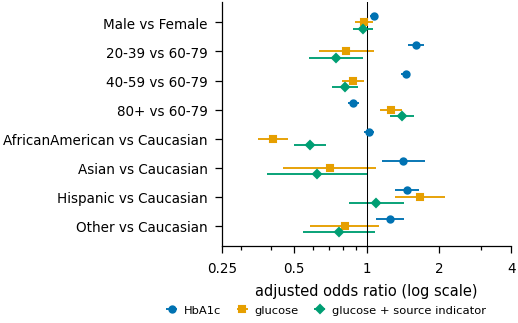

In [23]:
order = results["ordering"]
series = (
    ("HbA1c", "all_encounters", "hba1c_requested"),
    ("glucose", "all_encounters", "glucose_requested"),
    ("glucose + source indicator", "source_adjusted", "glucose_requested"),
)
rows = {}
for label, analysis, outcome in series:
    for t in order[analysis][outcome]["terms"].values():
        if t["tested"]:
            lo, hi = t["ci"]
            term = f"{t['level']} vs {t['reference']}"
            rows.setdefault(term, {})[label] = f"{t['odds_ratio']:.2f} [{lo:.2f}, {hi:.2f}]"
display(pd.DataFrame(rows).T)
rec = order["recording"]["glucose_requested"]
print(
    f"glucose results: {rec['share_of_events_source']:.1%} come from the "
    f"{rec['share_of_encounters_source']:.1%} of encounters with unknown admission type "
    f"(rate there {rec['rate_source']:.3f} vs {rec['rate_other']:.3f} elsewhere)"
)
figures.fig_ordering(order)

The figure's x-axis is the adjusted odds ratio of a recorded result (log scale). HbA1c results are
recorded more often for younger patients. The glucose field is mostly filled in the encounters
with unknown admission type (printed above; approved_ordering.md §4), so its apparent race
differences largely follow where the record comes from. With the source indicator the two race
contrasts whose CIs exclude 1 both move towards 1: Hispanic is no longer distinguishable from 1,
AfricanAmerican stays below 1 (last column). These odds ratios describe who has a recorded result,
not whether care was unequal.

## 6 Deployment and decision

The key numbers for the decision, read from the JSONs (each line names the table or figure above
it comes from):

In [24]:
lead = fair["leading_attribute"]
primary = fair["primary_model"]
d = summary["decision"][key]
ag = fair["groups"][lead]
young, old = list(ag)[0], list(ag)[-1]  # first and last age band
ma = mitig["audit"]["groups"][lead]
eo_base = fair["gaps"][key][lead]["eo_diff"]["estimate"]
eo_cap = mitig["effects"][f"eocap_{lead}"][f"eo_{lead}"]  # counterpart = same-number twin
cap_acc = mitig["effects"][f"eocap_{lead}"]["accuracy"]
prior = src["effects"]["without_prior_use@topq"]
rates = src["group_rates"]
prior_tprs = ", ".join(
    f"{grp} {rates['base__topq'][grp]['tpr']:.3f} → {rates['without_prior_use__topq'][grp]['tpr']:.3f}"
    for grp in ag
)
no_age = src["effects"]["no_age@topq"][f"eo_{lead}"]
glu = order["all_encounters"]["glucose_requested"]["terms"]
glu_src = order["source_adjusted"]["glucose_requested"]["terms"]
rec = order["recording"]["glucose_requested"]


def tpr(groups, grp, k):
    return groups[grp]["metrics"][k]["tpr"]["estimate"]


def tpr_path(grp):
    # TPR of one band: baseline / 80 % model (capacity rule) -> EO at capacity
    return (
        f"{grp} {tpr(ma, grp, 'base__topq'):.3f} / {tpr(ma, grp, 'val__topq'):.3f} → "
        f"{tpr(ma, grp, f'eocap_{lead}__eo'):.3f}"
    )


print(
    f"(a) usability (§5.2): {primary} accuracy − NIR {ci(d['acc_minus_nir'], 4)}, "
    f"PPV {d['ppv']['estimate']:.3f}; PR-AUC "
    f"{summary['ranking']['model:' + primary]['pr_auc']['estimate']:.3f} vs prevalence "
    f"{summary['prevalence']:.3f}; usable under any rule: "
    f"{any(v['usable'] for v in summary['decision'].values())}"
)
print(
    f"(b) age gap (§5.3): EO {ci(fair['gaps'][key][lead]['eo_diff'])}, null mean "
    f"{fair['gaps'][key][lead]['null']['mean']:.3f}; TPR {young} {tpr(ag, young, key):.3f} "
    f"vs {old} {tpr(ag, old, key):.3f}"
)
print(
    f"(c) levelling down (§5.4): EO baseline / same-number twin → EO at capacity: "
    f"{eo_base:.3f} / {eo_cap['counterpart']:.3f} → {eo_cap['mitigated']:.3f}; "
    f"TPR baseline / 80 % model → EO at capacity: {tpr_path(young)}, {tpr_path(old)}; "
    f"Δ accuracy {ci(cap_acc, 4, 'difference')}"
)
print(
    f"(d) sources (§5.5): without prior use Δ EO {ci(prior[f'eo_{lead}'], key='difference')}; "
    f"TPR full → without prior use: {prior_tprs}; Δ ROC-AUC {prior['roc_auc']['difference']:.3f}; "
    f"without age Δ EO "
    f"{ci(no_age, key='difference')}; proxy ROC-AUC for {lead} "
    f"{src['proxy'][lead]['macro']['estimate']:.3f}"
)
print(
    f"(e) glucose recording (§5.6): {rec['share_of_events_source']:.1%} of results from "
    f"{rec['share_of_encounters_source']:.1%} of encounters; with the source indicator "
    f"AfricanAmerican OR {glu['race=AfricanAmerican']['odds_ratio']:.2f} → "
    f"{glu_src['race=AfricanAmerican']['odds_ratio']:.2f}, Hispanic "
    f"{glu['race=Hispanic']['odds_ratio']:.2f} → {glu_src['race=Hispanic']['odds_ratio']:.2f}"
)

(a) usability (§5.2): rf accuracy − NIR -0.0566 [-0.0594, -0.0539], PPV 0.252; PR-AUC 0.216 vs prevalence 0.114; usable under any rule: False
(b) age gap (§5.3): EO 0.257 [0.192, 0.320], null mean 0.030; TPR 20-39 0.468 vs 80+ 0.211
(c) levelling down (§5.4): EO baseline / same-number twin → EO at capacity: 0.257 / 0.250 → 0.018; TPR baseline / 80 % model → EO at capacity: 20-39 0.468 / 0.457 → 0.222, 80+ 0.211 / 0.207 → 0.204; Δ accuracy -0.0090 [-0.0100, -0.0081]
(d) sources (§5.5): without prior use Δ EO -0.177 [-0.236, -0.107]; TPR full → without prior use: 20-39 0.468 → 0.245, 40-59 0.276 → 0.165, 60-79 0.233 → 0.210, 80+ 0.211 → 0.230; Δ ROC-AUC -0.045; without age Δ EO -0.070 [-0.086, -0.052]; proxy ROC-AUC for age_band 0.773
(e) glucose recording (§5.6): 79.7% of results from 10.2% of encounters; with the source indicator AfricanAmerican OR 0.41 → 0.58, Hispanic 1.66 → 1.10


**Decision** (letters refer to the lines printed above).

* **(a) Not usable by the approved gate.** No model and no decision rule has the whole confidence
  interval of accuracy − NIR above zero (§5.2 table and model figure). The models rank risk better
  than chance (PR-AUC above the prevalence), but at a fixed capacity most flagged patients are
  not readmitted. The model should not decide on its own who gets follow-up.
* **(b) The clearest disparity is by age.** Among the readmitted, the youngest band is flagged far
  more often than the oldest (§5.3 table and fairness figure), well above the no-disparity null;
  the sex and race gaps are within their nulls. Observed − predicted risk is near zero in every
  band; the ECE sits above its perfect-calibration value, so calibration is rough but does not
  explain the gap (§5.3 calibration table). The gap comes from how well the model ranks each band
  and from the shared cut-off (§5.5 within-group table), not from biased risk levels.
* **(c) The post-processors close the gap by levelling down.** EO at capacity closes the age gap
  by lowering the TPR of the young band towards the others, not by raising the old band (§5.4 TPR
  table), and ThresholdOptimizer lowers every band against the single threshold (which flags about
  as many); nobody gains. Kamiran–Calders reweighing widens the gap; cell balancing narrows it,
  mostly as class balancing (approved_mitigation.md §4). No arm passes the gate.
* **(d) The gap sits in the prior-use inputs and survives unawareness.** Dropping the prior-use
  block removes most of it, more than the same loss of ranking quality explains, but it narrows
  mostly by lowering the young bands' TPR, at a loss of ranking quality: the block carries the
  gap, removing it is no remedy (approved_sources.md §3). Dropping age removes only part, because
  the other inputs still predict the age band (§5.5).
* **(e) The glucose "race gap" is largely, not wholly, a recording pattern.** Most glucose results
  come from a small share of encounters (unknown admission type); with that indicator the Hispanic
  odds ratio is no longer distinguishable from 1 and the AfricanAmerican one moves towards 1 but
  stays below it (§5.6). They describe records, not unequal care.

**What a hospital should do:** use the score, if at all, as one input to a clinician's follow-up
list, not as the rule; monitor TPR by age band on its own data at its own capacity; not adopt
post-processing that closes the gap only by lowering detection in the young; and check how
laboratory results are recorded before reading test-ordering differences as unequal care.

## 7 Reproduce everything (optional)

The full run is five scripts in this order; each fitting script resumes per outer split from its
checkpoints (`outputs/approved/checkpoints`, git-ignored). `--n-jobs N` sets the CPU threads
(default: half of the CPUs, at least 2); it changes the run time, not the reported results
(`readmission/runtime.py`). `--quick` (first four scripts) is a one-repeat check run. The run
times of the saved run, read from the report headers:

In [25]:
for name in ("main", "fairness", "mitigation", "sources", "ordering"):
    lines = (ROOT / "outputs" / "reports" / f"approved_{name}.md").read_text(encoding="utf-8")
    header = next(line for line in lines.splitlines() if " min" in line)  # first line with a time
    times = [part.strip(" .") for part in header.replace("·", ",").split(",") if " min" in part]
    print(f"approved_{name}.md: " + "; ".join(times))
if live is not None:
    n_splits = len(summary["split_seconds"])
    print(
        f"live split here: {live_minutes:.1f} min at {runtime.resolve_n_jobs(N_THREADS)} threads "
        f"(approved models only) x {n_splits} outer splits = {live_minutes * n_splits:.0f} min "
        f"for the main fits alone, before the extensions and the mitigation and source refits"
    )

approved_main.md: model fitting 43.2 min (sum over splits); whole script 4.0 min
approved_fairness.md: 7.5 min
approved_mitigation.md: fitting 21.0 min (sum over splits); whole script 4.2 min
approved_sources.md: fitting 39.6 min (sum over splits); whole script 3.2 min
approved_ordering.md: Run time: 0.2 min
live split here: 3.5 min at 2 threads (approved models only) x 25 outer splits = 87 min for the main fits alone, before the extensions and the mitigation and source refits


The saved run was made on a laptop with more CPU threads than Colab (`readmission/runtime.py`
docstring). "sum over splits" adds up the fitting time of every outer split. "whole script" is
the last run that wrote the report, which only re-summarised the saved checkpoints (every split
had been fitted before), so it is shorter than the fitting time. The last line scales the live split
above to all outer splits on this machine. To rerun everything here, set `RUN_FULL = True` in §0:

In [26]:
SCRIPTS = (
    "run_approved.py",
    "run_fairness.py",
    "run_mitigation.py",
    "run_sources.py",
    "run_ordering.py",
)
if RUN_FULL:
    for script in SCRIPTS:
        print("running", script, flush=True)
        subprocess.run(
            [sys.executable, f"scripts/{script}", "--n-jobs", str(N_THREADS)], check=True
        )
    results = figures.load_results(ROOT)  # then rerun §5.2 onwards to see the new numbers
else:
    print(
        "RUN_FULL is False: the saved results were used. Commands:",
        *[f"python scripts/{s} --n-jobs {N_THREADS}" for s in SCRIPTS],
        sep="\n  ",
    )

RUN_FULL is False: the saved results were used. Commands:
  python scripts/run_approved.py --n-jobs 2
  python scripts/run_fairness.py --n-jobs 2
  python scripts/run_mitigation.py --n-jobs 2
  python scripts/run_sources.py --n-jobs 2
  python scripts/run_ordering.py --n-jobs 2
